# Multiaxial Concrete

In [1]:
import xara
from xara.units.si import GPa, MPa

E  = 26*GPa
Fc = 15*MPa
Ft =  1*MPa
nu = 0.2

ec = Fc/E
Gt = 0.073*Fc**0.18
Gc = 2.0*Gt*(Fc/Ft)**2

et = Ft/E

In [2]:
materials = [
    xara.MultiaxialMaterial("FariaPlasticDamage",
        E=E, 
        nu = nu,
        Fc = Fc,
        Ft = Ft,
        beta=0.590,
        Ap=2.5, 
        An=1, Bn=0.75,
        scale_peak=True,
    ),
    xara.MultiaxialMaterial("FariaPlasticDamage",
        E=E, 
        nu = nu,
        Fc = Fc,
        Ft = Ft,
        beta=0.590,
        Ap=2.5,
        An=3, Bn=0.75,
        scale_peak=True,
    ),
    xara.MultiaxialMaterial("ASDConcrete3D", E, nu,
                            fc=Fc, ft=Ft,
    ),
    # xara.MultiaxialMaterial("DruckerPrager",
    #     E=E,
    #     nu = nu,
    #     Fy = Fc,
    #     Fsat=1.2*Fc,
    # )
]

## Analysis

In [3]:

import numpy as np
n = 40
strains = [
    *np.linspace(0, -0.0025, n),
    *np.linspace(-0.0025, -0.0015, n),
    *np.linspace(-0.0015, -0.0035, n),
    *np.linspace(-0.0035, -0.0017, n),
    *np.linspace(-0.0017, -0.0060, n),
]

def strain_test(material):
    tau, sig, gam, eps = [], [], [], []

    # Create a temporary material to perform the test
    with material as tmp:
        for eps_zz in strains:
            # Voigt order: [xx, yy, zz, xy, xz, yz]
            e0 = -nu*eps_zz
            strain = (e0, e0, eps_zz, 0.0, 0.0, 0.0)
            stress = tmp.getStress(strain, commit=True)

            sig.append(-stress[2]/Fc)
            tau.append( stress[0]/Fc)
            eps.append(-strain[2])
            gam.append( strain[0])

    return tau, sig, gam, eps


/var/folders/18/xksr_xbx0d59fvx50dwhswkm0000gn/T/ipykernel_77517/4105134919.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


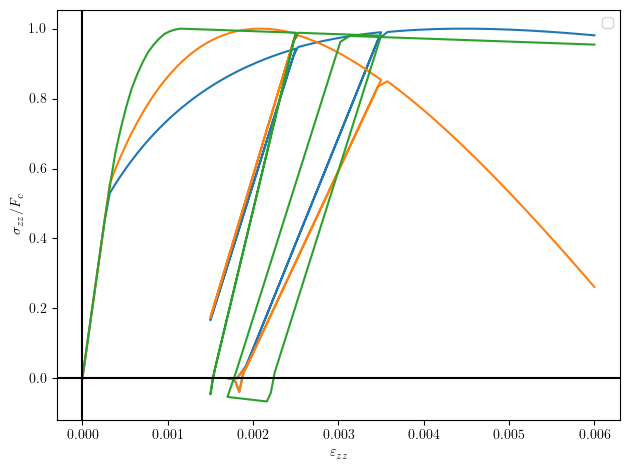

In [4]:


import matplotlib.pyplot as plt
fig, ax = plt.subplots()

for material in materials:

    tau, sig, gam, eps = strain_test(material)
    ax.plot(eps, sig)


ax.set_ylabel(r'$\sigma_{zz}/F_c$')
ax.set_xlabel(r'$\varepsilon_{zz}$')
ax.axvline(0, color='k', ls='-')
ax.axhline(0, color='k', ls='-')
ax.legend()
plt.tight_layout()

### Stress test

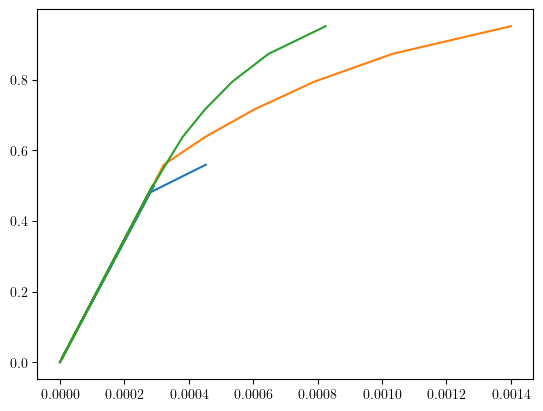

In [5]:
def stress_test(material):
    n = 20
    stress_history = [
        *np.linspace(0, -0.5*Fc, n),
        *np.linspace(-0.5*Fc, -0.01*Fc, n),
        *np.linspace(-0.01*Fc, -1.5*Fc, n),
        *np.linspace(-1.5*Fc, -0.01*Fc, n),
        *np.linspace(-0.01*Fc, -1.7*Fc, n),
    ]
    e = []
    s = []

    # Create a temporary material instance to run the test
    with material as tmp:
        for s_zz in stress_history:
            try:
                tmp.update(stress=[0.0, 0.0, s_zz, 0.0, 0.0, 0.0], commit=True)
            except:
                break
            e.append(-tmp.getStrain()[2])
            s.append(-s_zz/Fc)
    return e, s


fig, ax = plt.subplots()
for material in materials:
    e, s = stress_test(material)
    ax.plot(e, s, label=material.type)


## References
